# <b>lec05. 딥러닝 CNN - cat& dog 이미지 분류
* https://www.kaggle.com/c/dogs-vs-cats

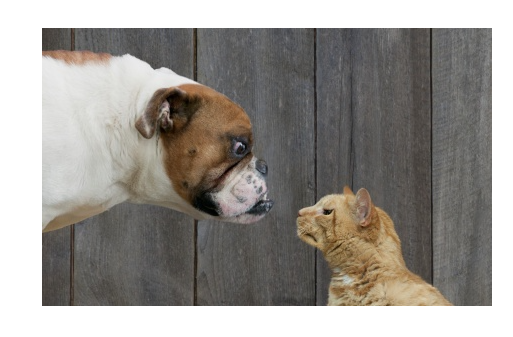

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split                     

#----------------------------------------------------------------------------------  DL모델 
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Conv2D, MaxPooling2D, GlobalAveragePooling2D #CNN
from tensorflow.keras.layers import  Flatten, Rescaling #일반 딥러닝

from tensorflow.keras.initializers import GlorotNormal #Xavier가 GlorotNormal로 바뀜
from tensorflow.keras.applications import MobileNetV2  #최소 이미지 크기 (32*32)

#----------------------------------------------------------------------------------  조기종료
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

#----------------------------------------------------------------------------------  랜덤 시드 고정
import tensorflow as tf
tf.random.set_seed(54546)
np.random.seed(54546)

#----------------------------------------------------------------------------------  EDA : 이미지로드
from tensorflow.keras.utils import load_img, img_to_array
from PIL import Image
from tensorflow.keras.utils import image_dataset_from_directory

import warnings
warnings.filterwarnings('ignore')

sns.set()

#-------------------- 차트 관련 속성 (한글처리, 그리드) -----------
plt.rcParams['font.family']= 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

#-------------------- 주피터 , 출력결과 넓이 늘리기 ---------------
# from IPython.core.display import display, HTML
from IPython.display import display, HTML
display(HTML("<style>.container{width:100% !important;}</style>"))
pd.set_option('display.max_rows', 100)
pd.set_option('display.max_columns', 100)
pd.set_option('max_colwidth', None)

# <b> DATA load

In [2]:
import os
img_ext = ('.jpg', '.jpeg', '.png', '.gif', '.bmp', '.webp') #우리는 다 jpg
img_list = [
    os.path.join('./dataset/catdog/train/cat/', f)
    for f in os.listdir('./dataset/catdog/train/cat/')
    if f.lower().endswith(img_ext)
]
print(  len(img_list) )
print(img_list[:10])

301
['./dataset/catdog/train/cat/cat.0.jpg', './dataset/catdog/train/cat/cat.1.jpg', './dataset/catdog/train/cat/cat.10.jpg', './dataset/catdog/train/cat/cat.100.jpg', './dataset/catdog/train/cat/cat.101.jpg', './dataset/catdog/train/cat/cat.102.jpg', './dataset/catdog/train/cat/cat.103.jpg', './dataset/catdog/train/cat/cat.104.jpg', './dataset/catdog/train/cat/cat.105.jpg', './dataset/catdog/train/cat/cat.106.jpg']


# EDA

## PIL

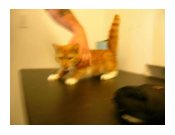

In [3]:
from PIL import Image #픽셀이 아닌 사진
plt.figure(figsize = (2,2))
img = Image.open("./dataset/catdog/train/cat/cat.0.jpg")
plt.imshow(img)
plt.grid(False)
plt.axis(False)
plt.show()

## keras.utils.load_img()

```python
keras.utils.load_img(
    path,
    color_mode="rgb",
    target_size=None,
    interpolation="nearest",
    keep_aspect_ratio=False,
)

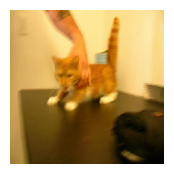

In [4]:
from tensorflow.keras.utils import load_img
plt.figure(figsize = (2,2))
img = load_img('./dataset/catdog/train/cat/cat.0.jpg',  target_size=(150,150)) # 원본 사진의 크기가 제각각인데 load하면 다 사이즈 맞춰짐
plt.imshow(img)
plt.grid(False)
plt.axis(False)
plt.show()

## keras.utils.image_dataset_from_directory()
* https://keras.io/api/data_loading/image/

<pre>
main_directory/                   C:\IT\workspace_ptyhon\dl\dataset\catdog\train
class_a/                                cat
...a_image_1.jpg
...a_image_2.jpg
class_b/                                dog
...b_image_1.jpg
...b_image_2.jpg
이런구조여야 사용가능

``` python
keras.utils.image_dataset_from_directory(
    directory,           #메인디렉토리
    labels="inferred",   #별도 라벨 불필요 = 라벨을 자동으로 추론
    label_mode="int",    # 라벨을 어떤 형태로 만드는지
                         # (int) sparse_categorical_crossentropy 라벨 정수형태, 닫중분류에서 많이 사용
                         #(categorical)categorical_crossentropy
                         # (binary) binary_crossentropy
    class_names=None,    # 학습 데이터 = None이면 main_directory내 모든 폴더 
    batch_size=32,       # 한 번에 모델에 넣는 이미지 수 
                         # 크다 == 학습속도 빠름 == 정확도 떨어짐
                         # 작다 == 학습속도 느림 == 정확도 올라감
    image_size=(256, 256),
    shuffle=True,        # 데이터 랜덤 섞기 = 모델 과적합 방지
    seed=None,           # 랜덤 고정값
    validation_split=None, #학습 / 검증 데이터 나누기

    color_mode="rgb",
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False,
    pad_to_aspect_ratio=False,
    data_format=None,
    format="tf",
    verbose=True,
)


In [5]:
train_dir = image_dataset_from_directory("./dataset/catdog/train"
                            ,image_size=(150, 150),  seed=4894
                            ,validation_split=0.2
                            , batch_size=32
                            , subset="training"
                            , label_mode = "binary")


val_dir = image_dataset_from_directory("./dataset/catdog/train"
                            ,image_size=(150, 150),  seed=4894
                            ,validation_split=0.2
                            , batch_size=32
                            , subset="validation"
                            , label_mode = "binary")


Found 602 files belonging to 2 classes.
Using 482 files for training.
Found 602 files belonging to 2 classes.
Using 120 files for validation.


# 모델

In [6]:
model = Sequential([
    Rescaling(1.0/255.0, input_shape=(150,150,3)), # ---- 전처리 가공(스케일링)

    #----------------------- ---------------------CNN
    Conv2D (filters = 16, kernel_size = (5,5), activation="relu"),
    MaxPooling2D(pool_size=(2, 2)), 
    Conv2D (filters = 32, kernel_size = (3,3), activation="relu"),
    MaxPooling2D(pool_size=(2, 2)),
    Conv2D (filters = 64, kernel_size = (3,3), activation="relu"),
    MaxPooling2D(pool_size=(2, 2)),
    
    Flatten( ),                                     # --------------- 평탄화작업
    Dense(256 , activation = "relu"),               # ------------ hidden layer 3
    Dense(1  , activation = "sigmoid")                # ------------ output layer 
])
model.compile(loss ="binary_crossentropy", optimizer = "adam", metrics=["accuracy"]) 

In [7]:
model.summary() 

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)                │ (None, 150, 150, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d (Conv2D)                      │ (None, 146, 146, 16)        │           1,216 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 73, 73, 16)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 71, 71, 32)          │           4,640 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 35, 35, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 33, 33, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 16, 16, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 16384)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 256)                 │       4,194,560 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │             257 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 4,219,169 (16.09 MB)

 Trainable params: 4,219,169 (16.09 MB)

 Non-trainable params: 0 (0.00 B)

In [8]:
fit_res = model.fit( train_dir, epochs=20, validation_data = val_dir )
loss, acc = model.evaluate(val_dir)
print(f"acc : {acc:.4f} , loss:{loss:.4f}")

Epoch 1/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 92ms/step - accuracy: 0.4772 - loss: 0.7618 - val_accuracy: 0.5500 - val_loss: 0.6878
Epoch 2/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 84ms/step - accuracy: 0.4896 - loss: 0.6917 - val_accuracy: 0.5667 - val_loss: 0.6905
Epoch 3/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 84ms/step - accuracy: 0.6079 - loss: 0.6831 - val_accuracy: 0.5917 - val_loss: 0.6795
Epoch 4/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 86ms/step - accuracy: 0.5871 - loss: 0.6587 - val_accuracy: 0.5667 - val_loss: 0.6754
Epoch 5/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 87ms/step - accuracy: 0.6846 - loss: 0.6101 - val_accuracy: 0.4917 - val_loss: 0.7422
Epoch 6/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 87ms/step - accuracy: 0.7282 - loss: 0.5370 - val_accuracy: 0.5167 - val_loss: 0.8009
Epoch 7/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 84ms/step - accuracy: 0.7946 - loss: 0.4521 - val_accuracy: 0.5250 - val_loss: 1.0397
Epoch 8/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 87ms/step - accuracy: 0.8589 - loss: 0.3748 - val_accuracy: 0.6333 - v

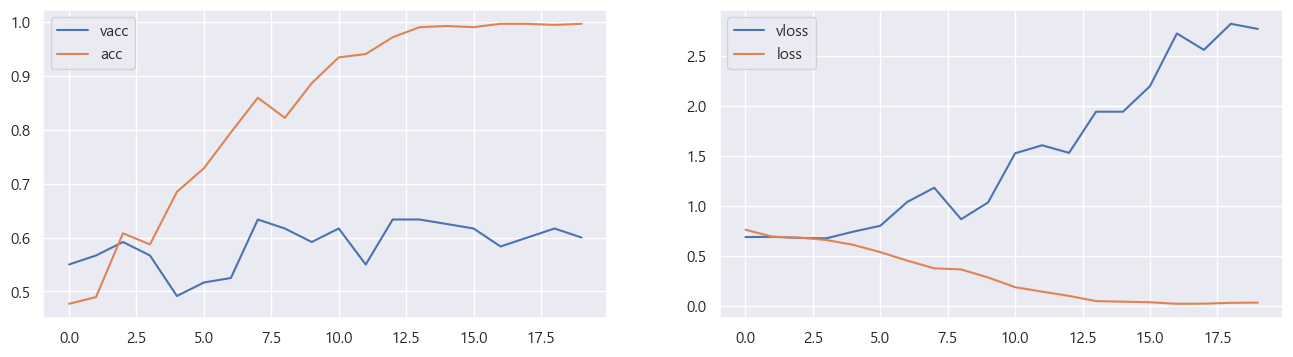

In [10]:
plt.figure(figsize=(16,4))
plt.subplot(1,2,1)
vacc = fit_res.history["val_accuracy"]
acc  = fit_res.history["accuracy"]
plt.plot(range(20), vacc , label="vacc")
plt.plot(range(20), acc  , label="acc")
plt.legend()

plt.subplot(1,2,2)
vloss = fit_res.history["val_loss"]
loss = fit_res.history["loss"]
plt.plot(range(20),vloss , label="vloss")
plt.plot(range(20),loss  , label="loss")
plt.legend()
plt.show()

학습이 잘 안됨ㅎㅋ

# <font color = red><b>조기종료
* https://keras.io/api/callbacks/

```python
keras.callbacks.ModelCheckpoint(
    filepath,                  #모델 저장 경로
    monitor="val_loss",        #체크 할 점수 어느점수에서 멈출지정하는기준
    save_best_only=True,       #점수가 좋아지면 저장
    save_weights_only=False,  #모델, 가중치 같이 저장
    verbose=0,
    
    
    mode="auto",
    save_freq="epoch",
    initial_value_threshold=None,
)

keras.callbacks.EarlyStopping(
    monitor="val_loss",      #체크 할 점수
    patience=0,              #연속적으로 N회 점수 개선이 없으면 종료 - 중간에 점수 좋으면 그 전 기록 리셋됨
    start_from_epoch=0,
    
    min_delta=0,
    verbose=0,
    mode="auto",
    baseline=None,
    restore_best_weights=False,

)

In [11]:
MY_CHECK_POINT = ModelCheckpoint(
                "./models/lec05_catdog_{epoch}_{val_accuracy:.4f}_{val_loss:.4f}.keras",                  #모델 저장 경로
                monitor="val_loss",        #체크 할 점수 어느점수에서 멈출지정하는기준
                save_best_only=True,       #점수가 좋아지면 저장
                save_weights_only=False,  #모델, 가중치 같이 저장
)

In [12]:
MY_EARLY_STOP = EarlyStopping(
    monitor="val_loss",     
    patience=5
)

# <font color=red><b>전이학습
* <b>ILSVRC(ImageNet Large Scale Visual Recognition Challenge)</b>
    - Train : 약 128만 장
    - Validation : 5만 장
    - Test : 10만 장
    - 총 클래스 : 1000개
    - https://www.image-net.org/challenges/LSVRC/
* <b>전이학습</b>
    - 잘 알려진 모델을 가져와 내 데이터에 맞게 모델을 튜닝(=가중치 보정)해서 학습하는 것
    - 적은 데이터셋 학습에 효율적
    - https://keras.io/api/applications/mobilenet/mobilenet_models/#mobilenetv2-function

![image](https://blog.kakaocdn.net/dn/OzIUv/btrs8AsKuH8/OHHLKL2orZNqyaoCzuckJ0/img.png)

```python
keras.applications.MobileNetV2(
    input_shape=None,                 # (150*150)
    weights="imagenet",               #ILSVRC공모전 제출 당시의 w값

    include_top=False,                #Flatten()이후 직접 구성
    
    include_top=True,                 # FC(평탄화)그대로 사용
    classes=1000,                     # 1000종
    classifier_activation="softmax",  # 다중분류
    
        
    alpha=1.0,
    input_tensor=None,
    pooling=None,
    name=None,
)


## <font color = blue><b>include_top = True

In [13]:
mobile_model = MobileNetV2(
    input_shape=(224,224,3),
    include_top=True)

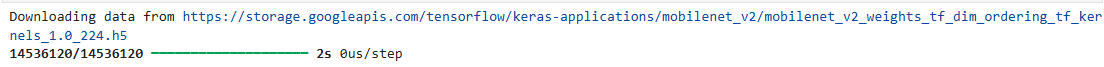

In [ ]:
#mobile_model.summary()

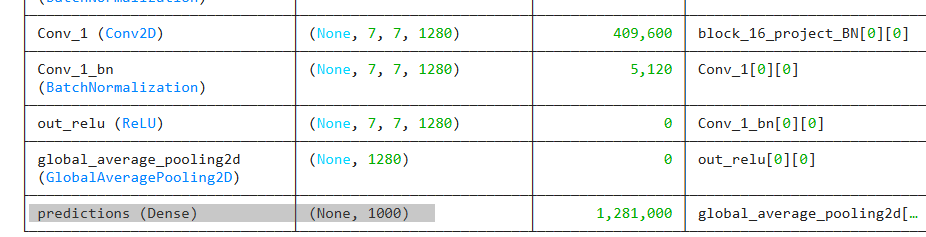

## <font color = blue><b>include_top = False

In [14]:
mobile_model = MobileNetV2(
    input_shape=(150,150,3),
    include_top=False)

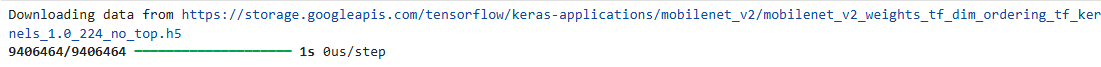

In [ ]:
#mobile_model.summary()

In [15]:
mobile_model.trainable = True

* <font color = red><b> 상당수 레이어의 w를 보정, 그러나 시간상 20레이어 w만 보정

In [16]:
for layer in mobile_model.layers[:140]: #그림의 흰부분(W그대로)
    layer.trainable = False

for layer in mobile_model.layers[140 : ]:#그림의 파란부분(W변경)
    layer.trainable = True

In [17]:
model = Sequential([
    Rescaling(1.0/255.0, input_shape=(150,150,3)), # ---- 전처리 가공(스케일링)

    #----------------------- ---------------------MobileNetV2
    mobile_model,
    
    Flatten( ),                                     # --------------- 평탄화작업
    Dense(256 , activation = "relu"),               # ------------ hidden layer 3
    Dense(1  , activation = "sigmoid")                # ------------ output layer 
])
model.compile(loss ="binary_crossentropy", optimizer = "adam", metrics=["accuracy"]) 

fit_res = model.fit( train_dir, epochs=40, validation_data = val_dir 
                     ,callbacks=[MY_CHECK_POINT, MY_EARLY_STOP])
loss, acc = model.evaluate(val_dir)
print(f"acc : {acc:.4f} , loss:{loss:.4f}")

Epoch 1/40
16/16 ━━━━━━━━━━━━━━━━━━━━ 9s 356ms/step - accuracy: 0.8651 - loss: 1.3619 - val_accuracy: 0.8667 - val_loss: 6.1674
Epoch 2/40
16/16 ━━━━━━━━━━━━━━━━━━━━ 5s 305ms/step - accuracy: 0.9668 - loss: 0.1441 - val_accuracy: 0.9167 - val_loss: 4.6305
Epoch 3/40
16/16 ━━━━━━━━━━━━━━━━━━━━ 4s 278ms/step - accuracy: 0.9917 - loss: 0.0584 - val_accuracy: 0.8833 - val_loss: 6.7014
Epoch 4/40
16/16 ━━━━━━━━━━━━━━━━━━━━ 4s 267ms/step - accuracy: 0.9378 - loss: 0.2548 - val_accuracy: 0.8667 - val_loss: 4.8341
Epoch 5/40
16/16 ━━━━━━━━━━━━━━━━━━━━ 4s 256ms/step - accuracy: 0.9979 - loss: 0.0199 - val_accuracy: 0.8083 - val_loss: 9.8560
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 128ms/step - accuracy: 0.8083 - loss: 9.8560
acc : 0.8083 , loss:9.8560


In [ ]:
# del model 
# del mobile_model

# <b>BEST Model

In [18]:
from tensorflow.keras.models import load_model
best_model = load_model("./models/lec05_catdog_2_0.9167_4.6305.keras")
best_model.summary()

## test 예측

In [ ]:
# img_list = [
#     os.path.join('./dataset/catdog/test/test/', f)
#     for f in os.listdir('./dataset/catdog/test/test/')
# ]
# print(  len(img_list) )
# print(img_list[:10])

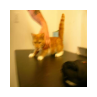

cat


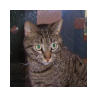

cat


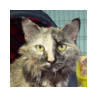

cat


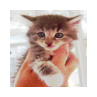

cat


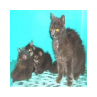

cat


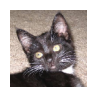

cat


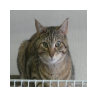

cat


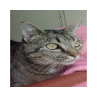

cat


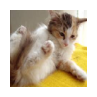

cat


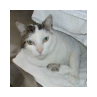

cat


In [20]:
from tensorflow.keras.utils import load_img, img_to_array
for f in img_list[:10]:
    test_img = load_img(f, target_size=(150,150))
    test_img_arr_3d = img_to_array(test_img)

    test_img_arr_4d = np.expand_dims(test_img_arr_3d, axis=0)
    #print(test_img, test_img_arr_3d.shape, test_img_arr_4d.shape)  #, test_img_arr )
    
    plt.figure(figsize=(1,1))
    plt.imshow(test_img)
    plt.grid(False)
    plt.axis(False)
    plt.show()

    proba = best_model.predict(test_img_arr_4d, verbose=0)
    score = proba[0][0]  
    
    if proba > 0.5 :
        print("dog")
    else:
        print("cat")

## 답안제출

In [21]:
test_dir = image_dataset_from_directory("./dataset/catdog/test"
                            ,image_size=(150, 150)
                            , batch_size=32
                            , seed=4894
                            , label_mode = None)
proba = best_model.predict(test_dir)
pred = (proba>0.5).astype(int)

Found 50 files.
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 102ms/step


In [22]:
print(pred.shape, pred[:5])
pred = pred.reshape(-10)
print(pred.shape, pred[:5])

(50, 1) [[1]
 [1]
 [1]
 [0]
 [0]]
(50,) [1 1 1 0 0]


# --------------------------